<a href="https://colab.research.google.com/github/Selvapriya05/Selvapriya-Codeboosters-2026/blob/main/Day_3/Day_3_Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY = 'e4c00c1634c23e0301a5298fec69b74c'
BASE_URL= 'https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai' , 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')
print('\nIMPORTANT: e4c00c1634c23e0301a5298fec69b74c with your actual key before running' )


API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT: e4c00c1634c23e0301a5298fec69b74c 


In [ ]:
#Extract : call api for each city

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get('http://api.openweathermap.org/data/2.5/weather', params=params, timeout=10)

    if response.status_code == 200:
      data = response.json()
      return {
          'city': city,
          'temperature': round(data['main']['temp'],1),
          'feels_like': round(data['main']['feels_like'],1),
          'description': data['weather'][0]['description'],
          'humidity': data['main']['humidity'],
          'pressure': data['main']['pressure'],
          'wind_speed': data['wind']['speed'],
          'condition': data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
         print(f'  ERROR {response.status_code} for {city}: {response.json().get("message", "")}')
         return None
 except requests.exceptions.ConnectionError:
     print(f'


    #call API for all cities
    print('Calling Weather API...')
    weather_records = []

    for city in CITIES:
        print(f'  Fetching: {city}...', end='')
        records = fetch_weather(city, API_KEY))
        if records:
            weather_records.append(records)
            print(f'  {record["temperature"]}C, {record["condition"]}')
        else:
            print('  FAILED')
        print(f' \nSucessfully fetched {len(weather_records)}/{len(CITIES)} cities')


In [ ]:
import requests

# Extract: call API for each city
def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    Returns a dictionary with weather metrics, or None on failure.
    """
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:
        response = requests.get(
            'http://api.openweathermap.org/data/2.5/weather',
            params=params,
            timeout=10
        )

        if response.status_code == 200:
            data = response.json()
            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like': round(data['main']['feels_like'], 1),
                'description': data['weather'][0]['description'],
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0)
            }

        else:
            print(f'ERROR {response.status_code} for {city}: {response.json().get("message", "")}')
            return None

    except requests.exceptions.ConnectionError:
        print(f'Connection error for {city}')
        return None


# -------------------------
# Call API for all cities
# -------------------------

print('Calling Weather API...')
weather_records = []

for city in CITIES:
    print(f'Fetching: {city}...', end=' ')

    record = fetch_weather(city, API_KEY)

    if record:
        weather_records.append(record)
        print(f'{record["temperature"]}°C, {record["condition"]}')
    else:
        print('FAILED')

print(f'\nSuccessfully fetched {len(weather_records)}/{len(CITIES)} cities')

Calling Weather API...
Fetching: Mumbai... 34.0°C, Haze
Fetching: Delhi... 44.0°C, Clear Sky
Fetching: Bangalore... 29.8°C, Scattered Clouds
Fetching: Chennai... 35.9°C, Few Clouds
Fetching: Hyderabad... 31.2°C, Broken Clouds
Fetching: Kolkata... 32.0°C, Haze
Fetching: Pune... 36.3°C, Overcast Clouds
Fetching: Jaipur... 42.6°C, Haze

Successfully fetched 8/8 cities


In [ ]:
# Step - 16 - Transform - Build from API results

import pandas as pd
weather_df = pd.DataFrame(weather_records)

print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'Data types:')
print(weather_df.dtypes)


Weather DataFrame created:
     city  temperature  feels_like      description  humidity  pressure  wind_speed        condition  visibility
   Mumbai         34.0        41.0             haze        59      1009        6.17             Haze        7000
    Delhi         44.0        41.1        clear sky        10       999        5.14        Clear Sky        7000
Bangalore         29.8        31.4 scattered clouds        54      1009        7.15 Scattered Clouds        8000
  Chennai         35.9        42.9       few clouds        53      1005        5.14       Few Clouds        6000
Hyderabad         31.2        33.2    broken clouds        51      1008        8.75    Broken Clouds        6000
  Kolkata         32.0        37.6             haze        62      1001        4.12             Haze        5000
     Pune         36.3        36.0  overcast clouds        27      1008        3.76  Overcast Clouds       10000
   Jaipur         42.6        41.3             haze        15      10

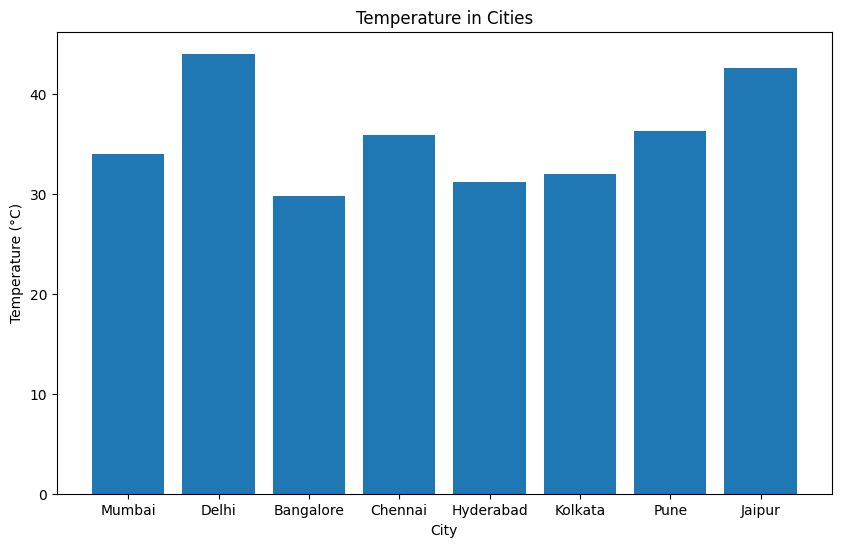

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

plt.figure(figsize=(10, 6))
plt.bar(weather_df['city'],
        weather_df['temperature'])
plt.title('Temperature in Cities')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.show()